In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
titanic = sns.load_dataset("titanic")

In [3]:
titanic.head()
#titanic.isnull().sum()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
features = ["pclass","sex","fare","embarked","age"]
target=["survived"]

In [5]:
#Missing data
from sklearn.impute import SimpleImputer

imp_median = SimpleImputer(strategy="median")
titanic[["age"]] = imp_median.fit_transform(titanic[["age"]])

imp_freq = SimpleImputer(strategy="most_frequent")
titanic[["embarked"]] = imp_freq.fit_transform(titanic[["embarked"]])

In [6]:
#Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

titanic["sex"] = le.fit_transform(titanic["sex"])
titanic["embarked"] = le.fit_transform(titanic["embarked"])

In [7]:
X = titanic[features]
y = titanic[target]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42, test_size=0.3)

In [9]:
#Decision tree - no pruning
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train,y_train)

DecisionTreeClassifier()

In [10]:
from sklearn.metrics import accuracy_score
y_pred = model.predict(X_test)

print("Accuracy score:",accuracy_score(y_test, y_pred))

Accuracy score: 0.7649253731343284


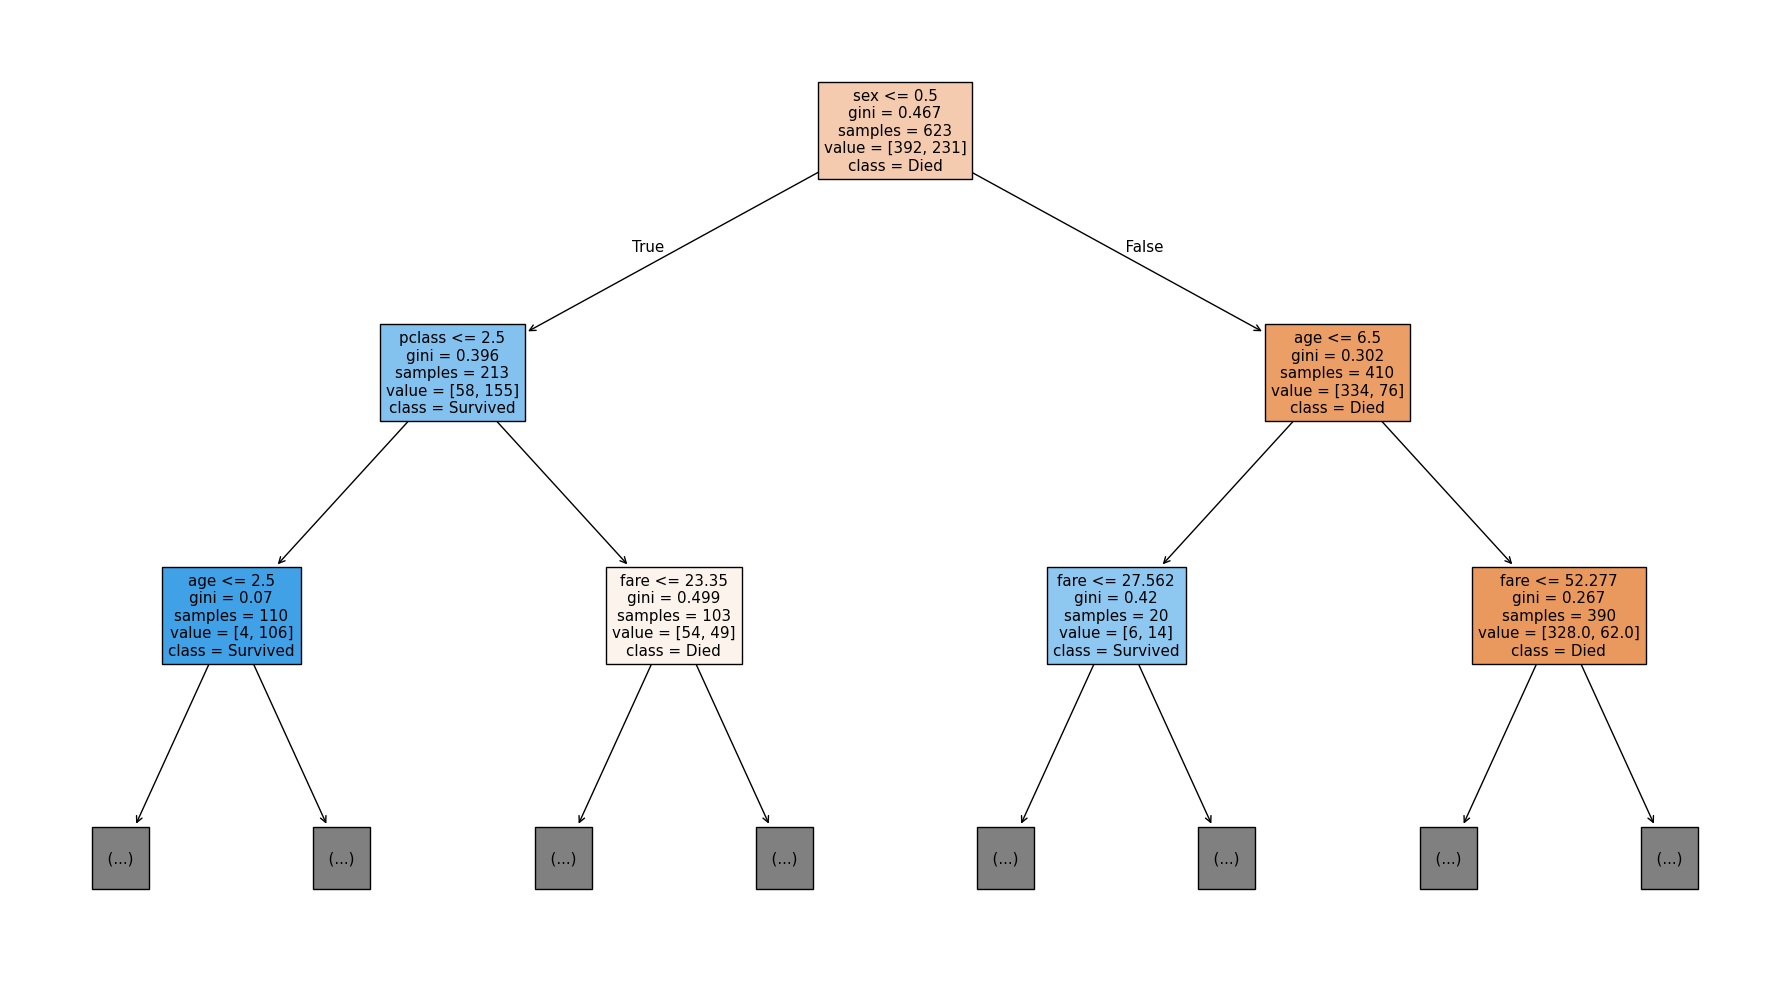

In [11]:
from sklearn.tree import plot_tree

plt.figure(figsize=(18,10))
plot_tree(
    model,
    feature_names = X.columns,
    class_names = ["Died","Survived"],
    filled=True,
    max_depth=2
)

plt.tight_layout()

#Decision tree with pruning

In [12]:
max_depths = [2,3,4,5,6,7,8,9,10]

for depth in max_depths:
    model = DecisionTreeClassifier(max_depth=depth)
    model.fit(X_train,y_train)
    acc = model.score(X_test,y_test)
    print("Accuracy score:",acc)

Accuracy score: 0.7723880597014925
Accuracy score: 0.8059701492537313
Accuracy score: 0.8246268656716418
Accuracy score: 0.7985074626865671
Accuracy score: 0.7835820895522388
Accuracy score: 0.7761194029850746
Accuracy score: 0.7910447761194029
Accuracy score: 0.7686567164179104
Accuracy score: 0.7873134328358209


In [13]:
min_samples_splits = [5,10,15,20,25,30]

for split in min_samples_splits:
    model = DecisionTreeClassifier(min_samples_split=split)
    
    model.fit(X_train,y_train)
    acc = model.score(X_test,y_test)
    print("Accuracy score:",acc)

Accuracy score: 0.7761194029850746
Accuracy score: 0.7761194029850746
Accuracy score: 0.7574626865671642
Accuracy score: 0.7835820895522388
Accuracy score: 0.7723880597014925
Accuracy score: 0.7723880597014925


In [14]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

DecisionTreeClassifier(random_state=42)

In [15]:
path = full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas

In [16]:
trees = []
for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(X_train,y_train)
    trees.append((model,alpha))

best_acc=0
best_alpha=0
for model,alpha in trees:
    curr_acc = model.score(X_test,y_test)
    if(curr_acc>best_acc):
        best_acc=curr_acc
        best_alpha=alpha

print(best_acc,best_alpha)
    

0.8208955223880597 0.0017121455323702516


In [17]:
best_model = DecisionTreeClassifier(random_state=42,ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)

DecisionTreeClassifier(ccp_alpha=np.float64(0.0017121455323702516),
                       random_state=42)

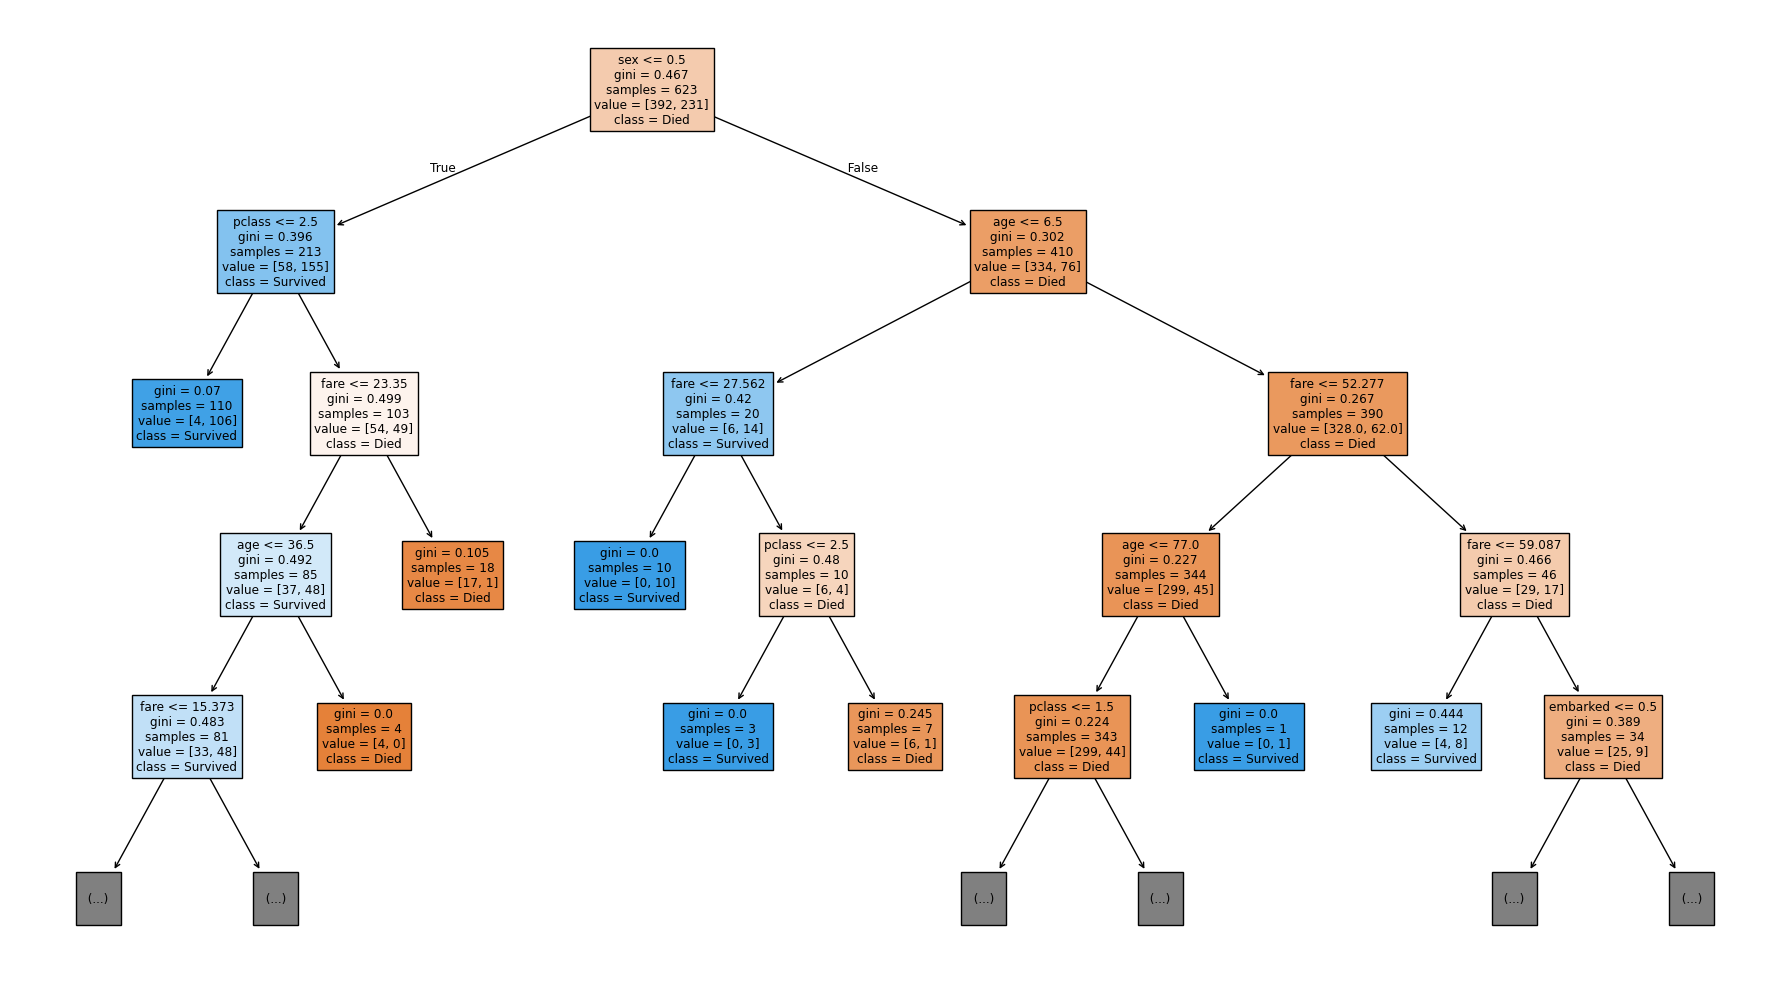

In [23]:
plt.figure(figsize=(18,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True,
    max_depth=4
)

plt.tight_layout()
plt.show()